In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('C:/Users/garap/Downloads/DATA ANALYSIS/robotaxi project/data/robotaxi_cleaned.csv')

In [3]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 861 entries, 0 to 860
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Report ID                        861 non-null    object
 1   Reporting Entity                 861 non-null    object
 2   Report Submission Date           861 non-null    object
 3   Incident Date                    861 non-null    object
 4   City                             859 non-null    object
 5   State                            859 non-null    object
 6   Roadway Type                     861 non-null    object
 7   Crash With                       861 non-null    object
 8   Highest Injury Severity Alleged  861 non-null    object
 9   SV Pre-Crash Movement            861 non-null    object
 10  SV Precrash Speed (MPH)          861 non-null    int64 
 11  Automation System Engaged?       861 non-null    object
 12  Engagement Status                861

,Report ID,Reporting Entity,Report Submission Date,Incident Date,City,State,Roadway Type,Crash With,Highest Injury Severity Alleged,SV Pre-Crash Movement,...,Within ODD?,Narrative,Incident Year,Incident Month,Incident Month Name,Incident Quarter,Reporting Delay Months,Weather Condition,Severity Group,Crash Counterpart Group
0,30270-11146,Waymo LLC,2025-06-01,2025-06-01,Austin,TX,Street,"Other, see Narrative",Property Damage. No Injured Reported,Proceeding Straight,...,Yes,"On June [XXX], 2025 at 1:28 PM CT a Waymo Auto...",2025,6,June,2,0,Unknown,No Injury,Other / Unknown
1,30270-11224,Waymo LLC,2025-06-01,2025-06-01,Mesa,AZ,Street,SUV,Property Damage. No Injured Reported,Proceeding Straight,...,Yes,"On June [XXX], 2025 at 5:34 PM MT a Waymo Auto...",2025,6,June,2,0,Clear,No Injury,Passenger Vehicle
2,30270-11218,Waymo LLC,2025-06-01,2025-06-01,San Francisco,CA,Intersection,Bus,Property Damage. No Injured Reported,Parked,...,Yes,"On June [XXX], 2025 at 6:48 PM PT a Waymo Auto...",2025,6,June,2,0,Unknown,No Injury,Commercial Vehicle
3,30270-11192,Waymo LLC,2025-06-01,2025-06-01,San Francisco,CA,Street,Passenger Car,Minor W/ Hospitalization,Stopped,...,Yes,"On June [XXX], 2025 at 2:27 PM PT a Waymo Auto...",2025,6,June,2,0,Clear,Minor Injury,Passenger Vehicle
4,30270-11204,Waymo LLC,2025-06-01,2025-06-01,Phoenix,AZ,Parking Lot,Van,No Injured Reported,Stopped,...,Yes,"On June [XXX], 2025 at 5:58 AM MT a Waymo Auto...",2025,6,June,2,0,Clear,No Injury,Passenger Vehicle


### Severity Distribution

In [4]:
severity_pct = (
    df['Severity Group']
    .value_counts(normalize=True) * 100
).round(2)

severity_pct

Severity Group
No Injury          87.92
Minor Injury        9.76
Unknown             1.63
Moderate Injury     0.58
Fatality            0.12
Name: proportion, dtype: float64

<Axes: xlabel='Severity Group'>

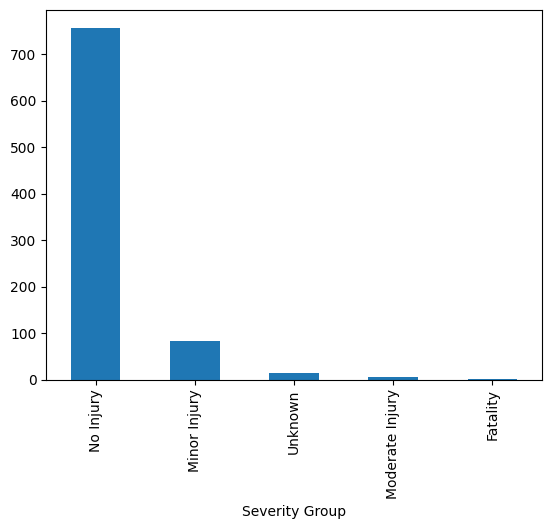

In [5]:
df['Severity Group'].value_counts().plot(kind='bar')

### Severity Distribution by Reporting Entity

In [6]:
pd.crosstab(
    df['Reporting Entity'],
    df['Severity Group']
)

Severity Group,Fatality,Minor Injury,Moderate Injury,No Injury,Unknown
Reporting Entity,,,,,
"Aurora Operations, Inc.",0,0,0,4,0
Avride Inc.,0,1,0,45,0
"Beep, Inc.",0,0,0,4,0
Hyundai Motor America,0,0,0,1,0
May Mobility,0,2,0,10,0
Motional,0,0,0,8,0
Nuro,0,0,0,4,0
"Ohmio, Inc.",0,1,0,0,0
Oxbotica,0,0,0,1,0


In [7]:
severity_entity_pct = pd.crosstab(
    df['Reporting Entity'],
    df['Severity Group'],
    normalize='index'
) * 100

severity_entity_pct.round(2)

Severity Group,Fatality,Minor Injury,Moderate Injury,No Injury,Unknown
Reporting Entity,,,,,
"Aurora Operations, Inc.",0.00,0.00,0.00,100.00,0.00
Avride Inc.,0.00,2.17,0.00,97.83,0.00
"Beep, Inc.",0.00,0.00,0.00,100.00,0.00
Hyundai Motor America,0.00,0.00,0.00,100.00,0.00
May Mobility,0.00,16.67,0.00,83.33,0.00
Motional,0.00,0.00,0.00,100.00,0.00
Nuro,0.00,0.00,0.00,100.00,0.00
"Ohmio, Inc.",0.00,100.00,0.00,0.00,0.00
Oxbotica,0.00,0.00,0.00,100.00,0.00


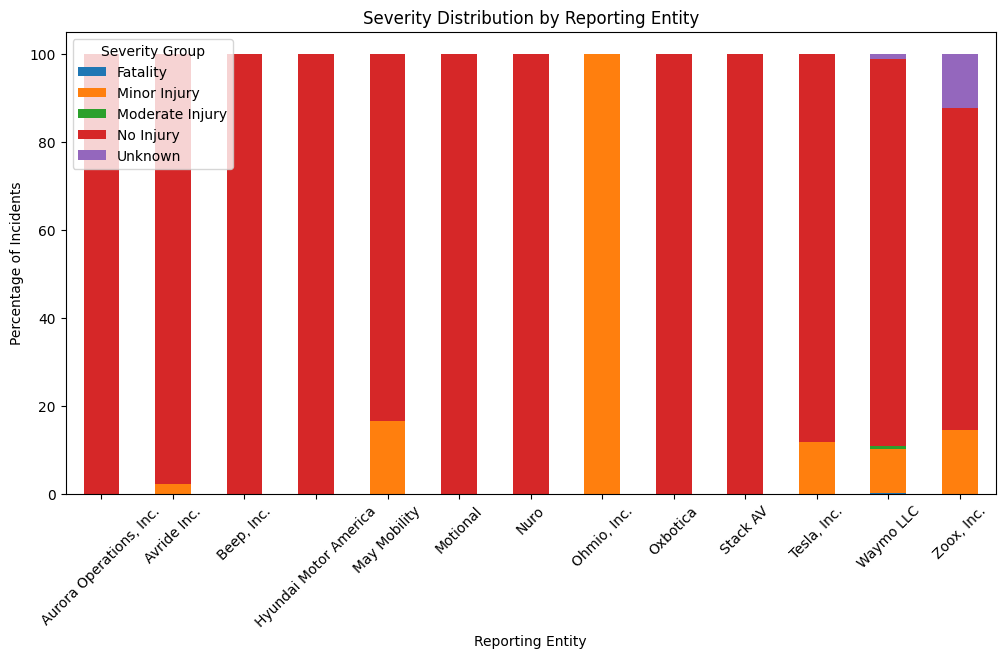

In [8]:
severity_entity_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Severity Distribution by Reporting Entity')
plt.ylabel('Percentage of Incidents')
plt.xlabel('Reporting Entity')
plt.xticks(rotation=45)
plt.legend(title='Severity Group')

plt.show()

### Roadway Risk Analysis

In [9]:
df['Roadway Type'].value_counts()

Roadway Type
Street               576
Intersection         204
Parking Lot           68
Highway / Freeway     13
Name: count, dtype: int64

In [10]:
(
    df['Roadway Type']
    .value_counts(normalize=True) * 100
).round(2)

Roadway Type
Street               66.90
Intersection         23.69
Parking Lot           7.90
Highway / Freeway     1.51
Name: proportion, dtype: float64

In [11]:
roadway_severity = pd.crosstab(
    df['Roadway Type'],
    df['Severity Group'],
    normalize='index'
) * 100

roadway_severity.round(2)

Severity Group,Fatality,Minor Injury,Moderate Injury,No Injury,Unknown
Roadway Type,,,,,
Highway / Freeway,0.00,0.00,0.00,84.62,15.38
Intersection,0.00,11.76,0.49,86.27,1.47
Parking Lot,0.00,2.94,0.00,97.06,0.00
Street,0.17,10.07,0.69,87.50,1.56


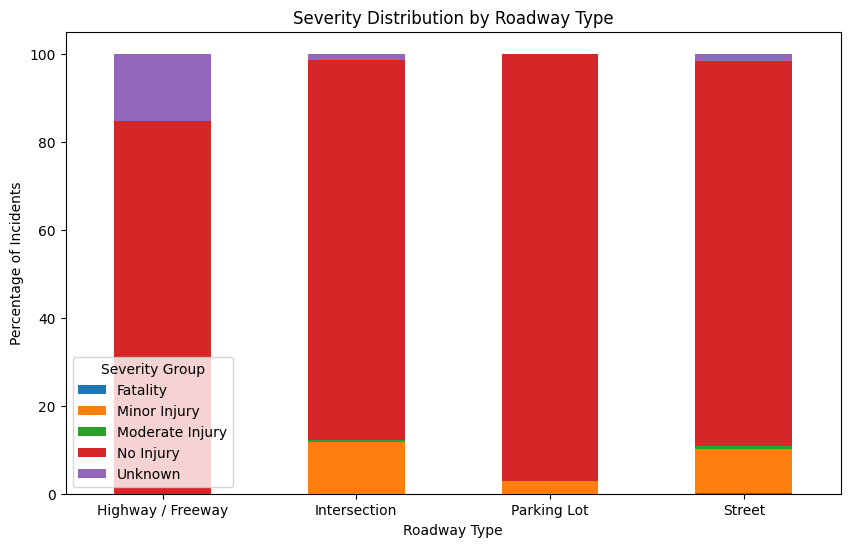

In [12]:
roadway_severity.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Severity Distribution by Roadway Type')
plt.ylabel('Percentage of Incidents')
plt.xlabel('Roadway Type')
plt.xticks(rotation=0)

plt.show()

### Counterpart Interaction Analysis

In [13]:
df['Crash Counterpart Group'].value_counts()

Crash Counterpart Group
Passenger Vehicle       591
Commercial Vehicle      119
Other / Unknown          65
Fixed Infrastructure     48
Vulnerable Road User     12
Two-Wheeler              10
Animal                    8
Emergency Vehicle         8
Name: count, dtype: int64

In [14]:
(
    df['Crash Counterpart Group']
    .value_counts(normalize=True) * 100
).round(2)

Crash Counterpart Group
Passenger Vehicle       68.64
Commercial Vehicle      13.82
Other / Unknown          7.55
Fixed Infrastructure     5.57
Vulnerable Road User     1.39
Two-Wheeler              1.16
Animal                   0.93
Emergency Vehicle        0.93
Name: proportion, dtype: float64

In [15]:
counterpart_group_severity = pd.crosstab(
    df['Crash Counterpart Group'],
    df['Severity Group'],
    normalize='index'
) * 100

counterpart_group_severity.round(2)

Severity Group,Fatality,Minor Injury,Moderate Injury,No Injury,Unknown
Crash Counterpart Group,,,,,
Animal,0.0,0.00,0.00,75.00,25.00
Commercial Vehicle,0.0,3.36,0.00,95.80,0.84
Emergency Vehicle,0.0,0.00,0.00,100.00,0.00
Fixed Infrastructure,0.0,6.25,0.00,93.75,0.00
Other / Unknown,0.0,0.00,0.00,95.38,4.62
Passenger Vehicle,0.0,11.51,0.68,86.63,1.18
Two-Wheeler,10.0,20.00,0.00,60.00,10.00
Vulnerable Road User,0.0,58.33,8.33,33.33,0.00


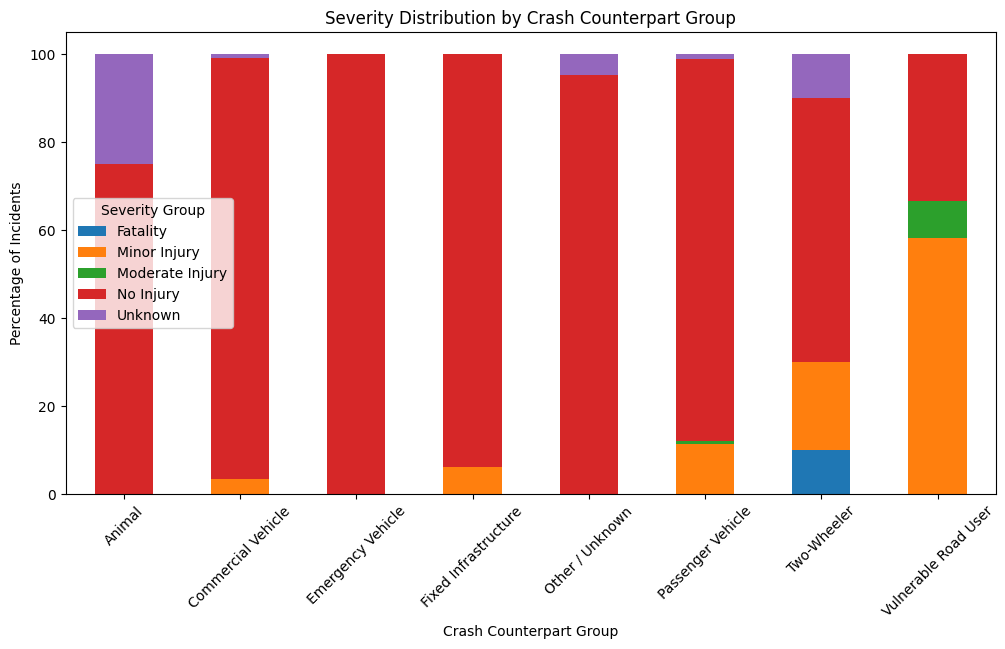

In [16]:
counterpart_group_severity.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Severity Distribution by Crash Counterpart Group')
plt.ylabel('Percentage of Incidents')
plt.xlabel('Crash Counterpart Group')
plt.xticks(rotation=45)

plt.show()

### Geographic Intelligence Analysis

In [17]:
df['State'].value_counts()

State
CA    470
TX    159
AZ    138
GA     36
NV     25
FL     18
DC      5
PA      3
MN      2
TN      2
CO      1
Name: count, dtype: int64

In [18]:
(
    df['State']
    .value_counts(normalize=True) * 100
).round(2)

State
CA    54.71
TX    18.51
AZ    16.07
GA     4.19
NV     2.91
FL     2.10
DC     0.58
PA     0.35
MN     0.23
TN     0.23
CO     0.12
Name: proportion, dtype: float64

In [19]:
df['City'].value_counts().head(15)

City
San Francisco     239
Los Angeles       143
Austin            113
Phoenix            78
Atlanta            33
Tempe              30
Dallas             30
Scottsdale         20
Las Vegas          19
Santa Monica       15
Inglewood          11
Miami               8
Mountain View       8
West Hollywood      7
Culver City         6
Name: count, dtype: int64

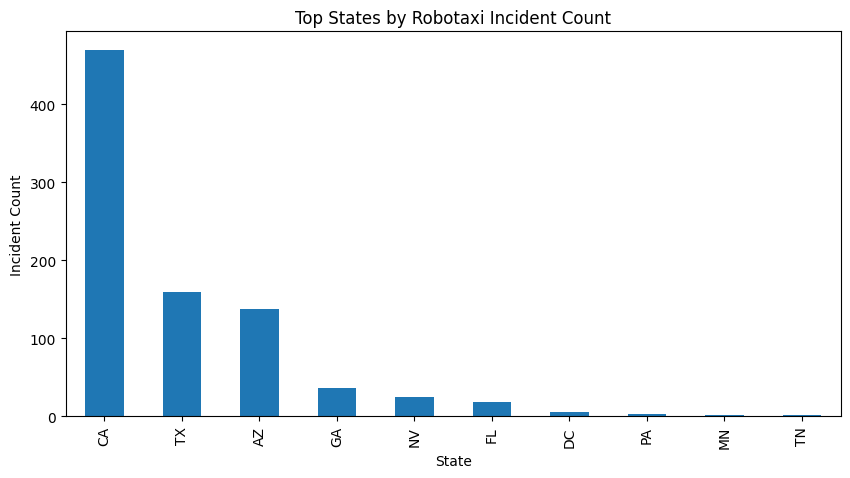

In [20]:
df['State'].value_counts().head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top States by Robotaxi Incident Count')
plt.ylabel('Incident Count')
plt.xlabel('State')

plt.show()

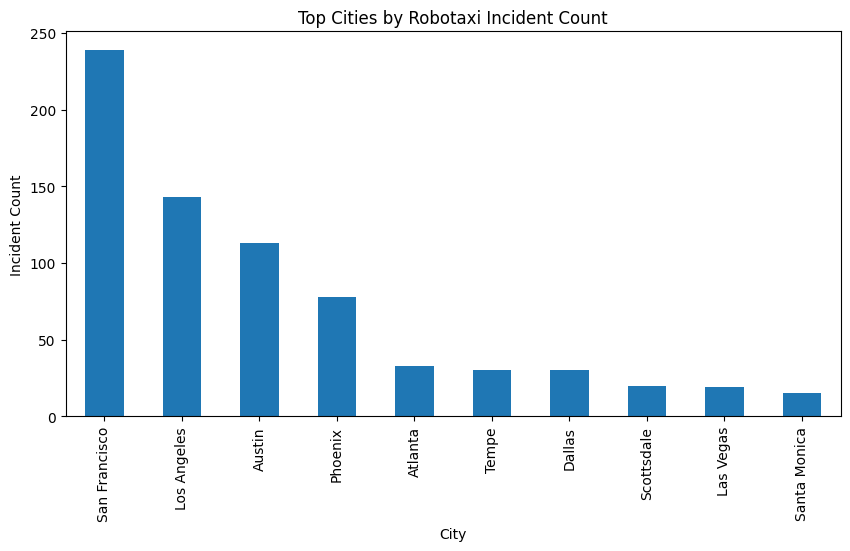

In [21]:
df['City'].value_counts().head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top Cities by Robotaxi Incident Count')
plt.ylabel('Incident Count')
plt.xlabel('City')

plt.show()

### Weather Severity Analysis 

In [22]:
weather_order = [
    'Clear',
    'Rain',
    'Fog/Smoke/Haze',
    'Unknown'
]

df['Weather Condition'] = pd.Categorical(
    df['Weather Condition'],
    categories=weather_order,
    ordered=True
)

<Axes: xlabel='Weather Condition'>

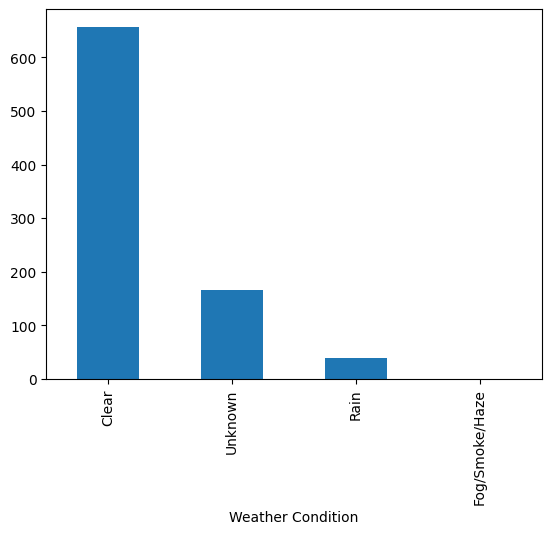

In [23]:
df['Weather Condition'].value_counts().plot(kind='bar')

In [58]:
weather_severity = pd.crosstab(
    df['Weather Condition'],
    df['Severity Group'],
    normalize='index'
) * 100

weather_severity.round(2)

Severity Group,Fatality,Minor Injury,Moderate Injury,No Injury,Unknown
Weather Condition,,,,,
Clear,0.15,9.89,0.61,87.52,1.83
Rain,0.00,7.89,0.00,86.84,5.26
Unknown,0.00,9.64,0.60,89.76,0.00


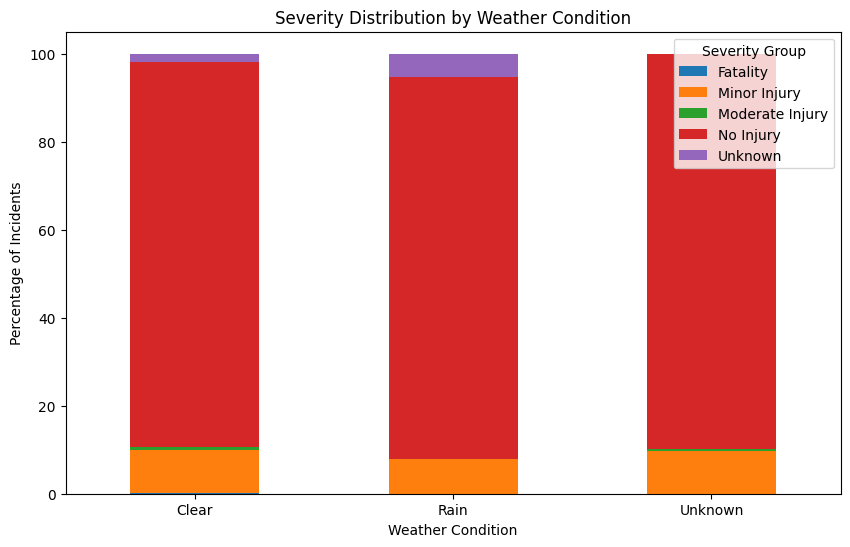

In [59]:
weather_severity.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Severity Distribution by Weather Condition')
plt.ylabel('Percentage of Incidents')
plt.xlabel('Weather Condition')
plt.xticks(rotation=0)

plt.show()

### Temporal Incident Analysis

In [60]:
monthly_incidents = (
    df.groupby(
        ['Incident Year', 'Incident Month']
    )
    .size()
    .reset_index(name='Incident Count')
)

monthly_incidents

,Incident Year,Incident Month,Incident Count
0,2025,4,1
1,2025,6,60
2,2025,7,66
3,2025,8,61
4,2025,9,67
5,2025,10,97
6,2025,11,112
7,2025,12,109
8,2026,1,118
9,2026,2,92


In [61]:
monthly_incidents['Year-Month'] = (
    monthly_incidents['Incident Year'].astype(str)
    + '-'
    + monthly_incidents['Incident Month'].astype(str).str.zfill(2)
)

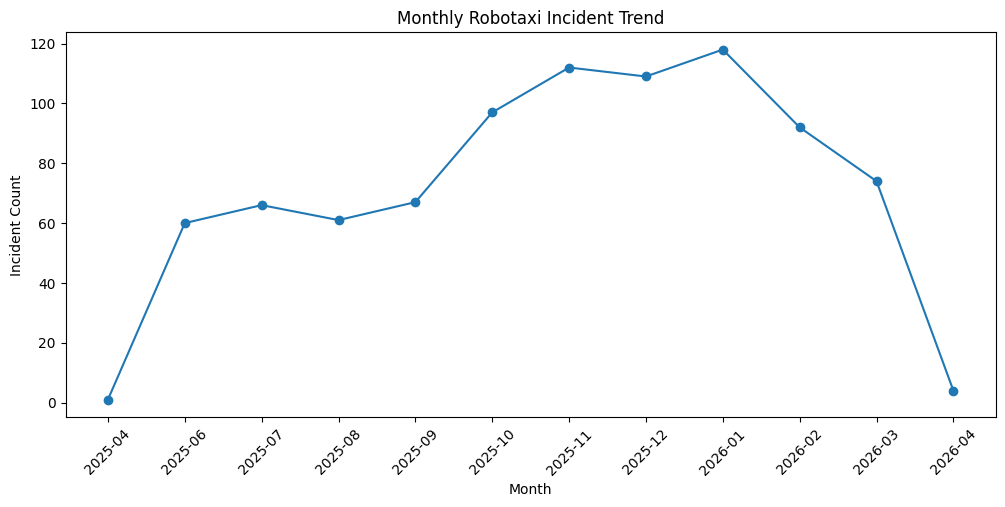

In [62]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_incidents['Year-Month'],
    monthly_incidents['Incident Count'],
    marker='o'
)

plt.title('Monthly Robotaxi Incident Trend')
plt.xlabel('Month')
plt.ylabel('Incident Count')

plt.xticks(rotation=45)

plt.show()

### Entity Growth & Deployment Scaling

#### Monthly Trend by Major Operators

In [63]:
major_entities = [
    'Waymo LLC',
    'Tesla, Inc.',
    'Zoox, Inc.',
    'Avride Inc.'
]

entity_monthly = (
    df[df['Reporting Entity'].isin(major_entities)]
    .groupby([
        'Incident Year',
        'Incident Month',
        'Reporting Entity'
    ])
    .size()
    .reset_index(name='Incident Count')
)

In [64]:
entity_monthly['Year-Month'] = (
    entity_monthly['Incident Year'].astype(str)
    + '-'
    + entity_monthly['Incident Month'].astype(str).str.zfill(2)
)

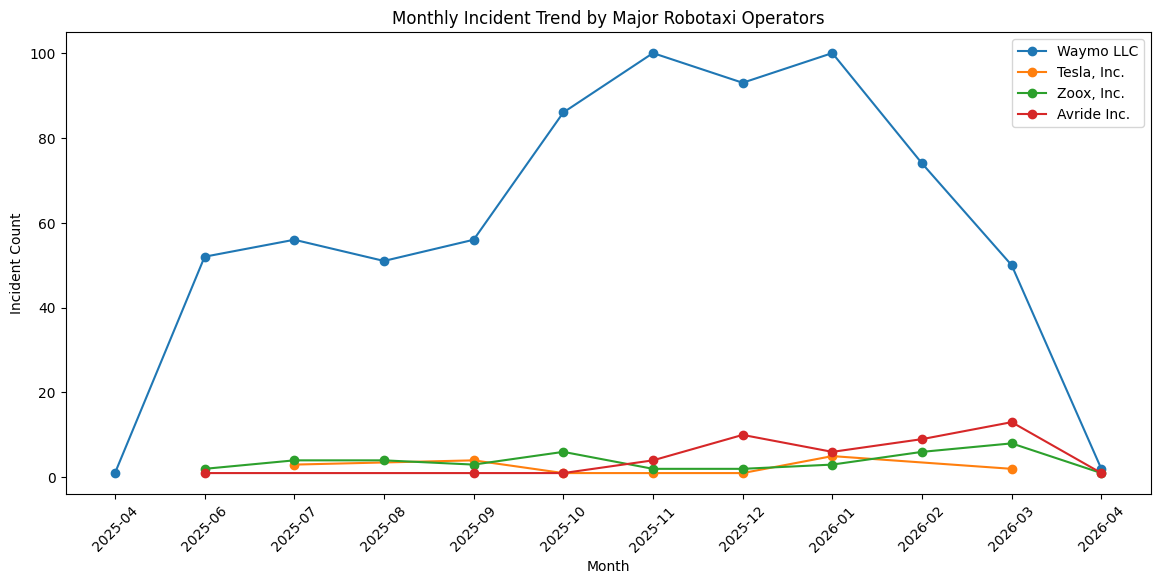

In [65]:
plt.figure(figsize=(14,6))

for entity in major_entities:

    subset = entity_monthly[
        entity_monthly['Reporting Entity'] == entity
    ]

    plt.plot(
        subset['Year-Month'],
        subset['Incident Count'],
        marker='o',
        label=entity
    )

plt.title('Monthly Incident Trend by Major Robotaxi Operators')

plt.xlabel('Month')
plt.ylabel('Incident Count')

plt.xticks(rotation=45)

plt.legend()

plt.show()

### Reporting delay Distribution

In [66]:
delay_counts = df['Reporting Delay Months'].value_counts().sort_index()

In [67]:
delay_pct = (
    df['Reporting Delay Months']
    .value_counts(normalize=True)
    .sort_index() * 100
).round(2)

delay_pct

Reporting Delay Months
0    45.41
1    51.92
2     1.28
3     0.23
4     0.23
5     0.12
6     0.46
8     0.35
Name: proportion, dtype: float64

In [68]:
delay_dist = pd.DataFrame({
    'Count': delay_counts,
    'Percentage': delay_pct
})

delay_dist

,Count,Percentage
Reporting Delay Months,,
0,391,45.41
1,447,51.92
2,11,1.28
3,2,0.23
4,2,0.23
5,1,0.12
6,4,0.46
8,3,0.35


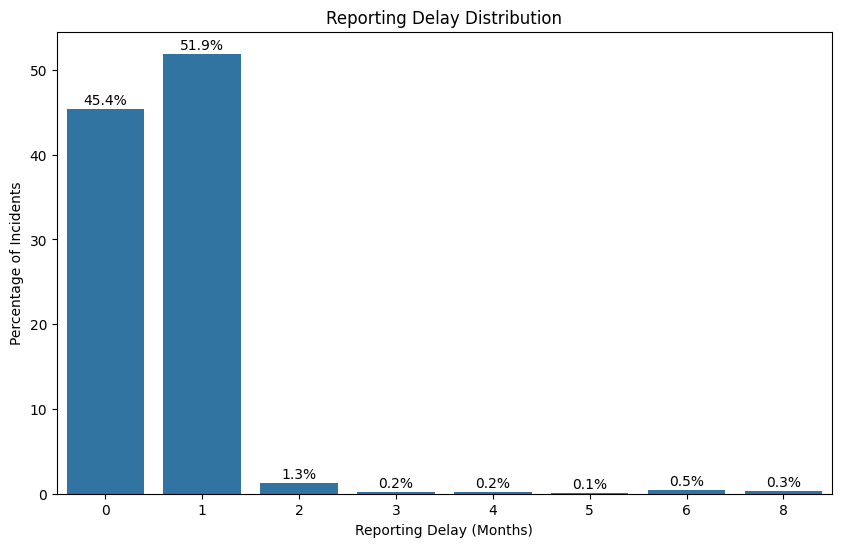

In [69]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=delay_dist.index,
    y=delay_dist['Percentage'],
)

plt.title('Reporting Delay Distribution')
plt.xlabel('Reporting Delay (Months)')
plt.ylabel('Percentage of Incidents')

# percentage labels on top
for i, v in enumerate(delay_dist['Percentage']):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center')

plt.show()

#### Reporting Delay by Severity

In [70]:
delay_severity = pd.crosstab(
    df['Reporting Delay Months'],
    df['Severity Group'],
    normalize='index'
) * 100

delay_severity.round(2)

Severity Group,Fatality,Minor Injury,Moderate Injury,No Injury,Unknown
Reporting Delay Months,,,,,
0,0.26,13.81,1.28,83.12,1.53
1,0.00,5.59,0.00,92.84,1.57
2,0.00,18.18,0.00,72.73,9.09
3,0.00,0.00,0.00,100.00,0.00
4,0.00,50.00,0.00,50.00,0.00
5,0.00,0.00,0.00,100.00,0.00
6,0.00,0.00,0.00,100.00,0.00
8,0.00,66.67,0.00,33.33,0.00


In [71]:
delay_entity = pd.crosstab(
    df['Reporting Entity'],
    df['Reporting Delay Months'],
    normalize='index'
) * 100

delay_entity.round(2)

Reporting Delay Months,0,1,2,3,4,5,6,8
Reporting Entity,,,,,,,,
"Aurora Operations, Inc.",0.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00
Avride Inc.,30.43,67.39,2.17,0.00,0.00,0.00,0.00,0.00
"Beep, Inc.",25.00,75.00,0.00,0.00,0.00,0.00,0.00,0.00
Hyundai Motor America,0.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00
May Mobility,8.33,83.33,0.00,0.00,8.33,0.00,0.00,0.00
Motional,25.00,75.00,0.00,0.00,0.00,0.00,0.00,0.00
Nuro,0.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00
"Ohmio, Inc.",0.00,0.00,100.00,0.00,0.00,0.00,0.00,0.00
Oxbotica,0.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00


In [72]:
delay_entity = delay_entity.sort_values(by=0, ascending=False)

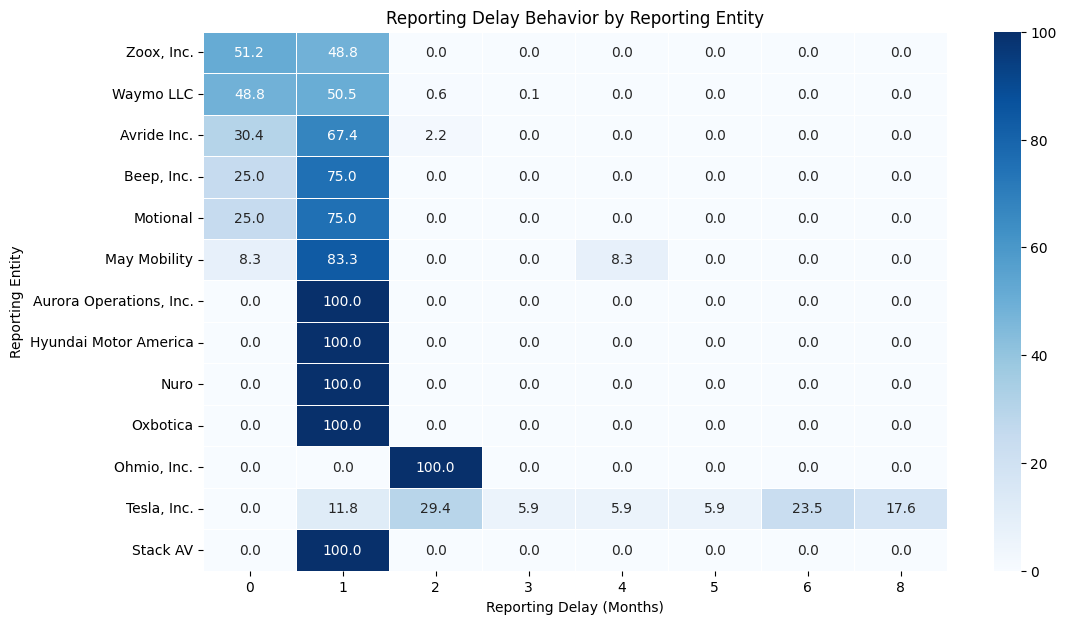

In [73]:
plt.figure(figsize=(12,7))

sns.heatmap(
    delay_entity,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    linewidths=0.5
)

plt.title('Reporting Delay Behavior by Reporting Entity')
plt.xlabel('Reporting Delay (Months)')
plt.ylabel('Reporting Entity')

plt.show()

### Severity by Reporting Delay

In [74]:
severity_delay = pd.crosstab(
    df['Reporting Delay Months'],
    df['Severity Group'],
    normalize='index'
) * 100

severity_delay = severity_delay.round(2)

severity_delay

Severity Group,Fatality,Minor Injury,Moderate Injury,No Injury,Unknown
Reporting Delay Months,,,,,
0,0.26,13.81,1.28,83.12,1.53
1,0.00,5.59,0.00,92.84,1.57
2,0.00,18.18,0.00,72.73,9.09
3,0.00,0.00,0.00,100.00,0.00
4,0.00,50.00,0.00,50.00,0.00
5,0.00,0.00,0.00,100.00,0.00
6,0.00,0.00,0.00,100.00,0.00
8,0.00,66.67,0.00,33.33,0.00


In [75]:
severity_order = [
    'No Injury',
    'Minor Injury',
    'Moderate Injury',
    'Fatality',
    'Unknown'
]

severity_delay = severity_delay[severity_order]

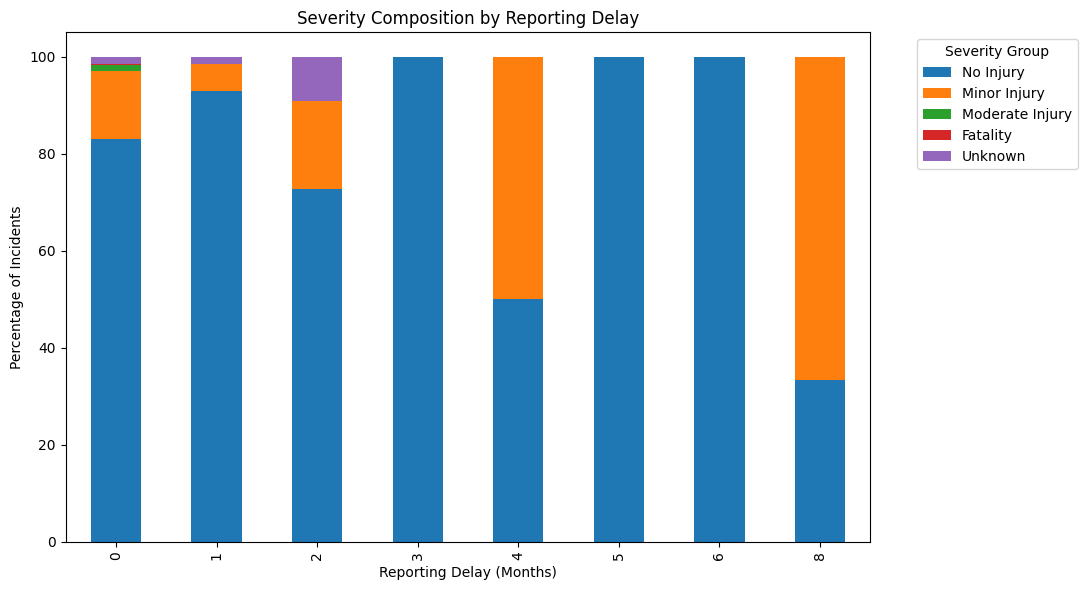

In [76]:
severity_delay.plot(
    kind='bar',
    stacked=True,
    figsize=(11,6)
)

plt.title('Severity Composition by Reporting Delay')
plt.xlabel('Reporting Delay (Months)')
plt.ylabel('Percentage of Incidents')

plt.legend(
    title='Severity Group',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()